In [2]:
import pandas as pd

df = pd.read_csv("Datos/planets.csv")
df.head()

,rowid,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,st_masserr1,st_masserr2,st_masslim,st_massblend,st_rad,st_raderr1,st_raderr2,st_radlim,st_radblend,rowupdate
0,1,11 Com,b,Radial Velocity,1,326.03,0.32,-0.32,0.0,1.290,...,0.30,-0.30,0.0,0.0,19.00,2.00,-2.00,0.0,0.0,2014-05-14
1,2,11 UMi,b,Radial Velocity,1,516.22,3.25,-3.25,0.0,1.540,...,0.25,-0.25,0.0,0.0,24.08,1.84,-1.84,0.0,0.0,2014-05-14
2,3,14 And,b,Radial Velocity,1,185.84,0.23,-0.23,0.0,0.830,...,0.10,-0.20,0.0,0.0,11.00,1.00,-1.00,0.0,0.0,2014-05-14
3,4,14 Her,b,Radial Velocity,1,1773.40,2.50,-2.50,0.0,2.770,...,0.05,-0.05,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2014-05-14
4,5,16 Cyg B,b,Radial Velocity,1,798.50,1.00,-1.00,0.0,1.681,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2015-09-10


## Limpieza de Datos (Data Cleaning)

- **Filtro**: Seleccionar solo las columnas relevantes para el análisis, eliminando columnas de error, flags técnicos y redundancias.
- **Nulos**: Identificar columnas vacías. Decidir si se borran o imputan (justificándolo en un comentario).
- **Duplicados**: Verificar registros repetidos por nombre de estrella y letra de planeta.
- **Outliers**: Revisar valores físicamente imposibles en las variables numéricas.

In [3]:
# ============================================================
# Limpieza de Datos (Data Cleaning)
# ============================================================

print(f"El dataset tiene {len(df)} filas y {df.shape[1]} columnas")
print(f"\nTipos de datos:")
print(df.dtypes.value_counts())
df.head()

El dataset tiene 3372 filas y 67 columnas

Tipos de datos:
float64    53
str         8
int64       6
Name: count, dtype: int64


,rowid,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbpererr1,pl_orbpererr2,pl_orbperlim,pl_orbsmax,...,st_masserr1,st_masserr2,st_masslim,st_massblend,st_rad,st_raderr1,st_raderr2,st_radlim,st_radblend,rowupdate
0,1,11 Com,b,Radial Velocity,1,326.03,0.32,-0.32,0.0,1.290,...,0.30,-0.30,0.0,0.0,19.00,2.00,-2.00,0.0,0.0,2014-05-14
1,2,11 UMi,b,Radial Velocity,1,516.22,3.25,-3.25,0.0,1.540,...,0.25,-0.25,0.0,0.0,24.08,1.84,-1.84,0.0,0.0,2014-05-14
2,3,14 And,b,Radial Velocity,1,185.84,0.23,-0.23,0.0,0.830,...,0.10,-0.20,0.0,0.0,11.00,1.00,-1.00,0.0,0.0,2014-05-14
3,4,14 Her,b,Radial Velocity,1,1773.40,2.50,-2.50,0.0,2.770,...,0.05,-0.05,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2014-05-14
4,5,16 Cyg B,b,Radial Velocity,1,798.50,1.00,-1.00,0.0,1.681,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,NaN,0.0,2015-09-10


In [4]:
# --- 2. Nulos: Identificar columnas con valores faltantes ---

print("Valores nulos por columna:")
print(df.isnull().sum())

Valores nulos por columna:
rowid              0
pl_hostname        0
pl_letter          0
pl_discmethod      0
pl_pnum            0
                ... 
st_raderr1       417
st_raderr2       494
st_radlim        358
st_radblend      187
rowupdate          0
Length: 67, dtype: int64


In [5]:
# Hacemos una copia para no modificar el original
df_clean = df.copy()

# Eliminamos columnas con más del 80% de nulos porque no sirven para el análisis
pct_nulos = df_clean.isnull().mean()
cols_muchos_nulos = pct_nulos[pct_nulos > 0.80].index.tolist()
print(f"Columnas con >80% nulos (se eliminan): {cols_muchos_nulos}")
df_clean.drop(columns=cols_muchos_nulos, inplace=True)

# Eliminamos columnas de error (*err1, *err2) porque son márgenes de incertidumbre
cols_error = [col for col in df_clean.columns if col.endswith('err1') or col.endswith('err2')]
print(f"\nColumnas de error eliminadas: {cols_error}")
df_clean.drop(columns=cols_error, inplace=True)

# Eliminamos columnas de flags técnicos (*lim, *blend) que no aportan al análisis
cols_flags = [col for col in df_clean.columns if col.endswith('lim') or col.endswith('blend')]
print(f"\nColumnas de flags eliminadas: {cols_flags}")
df_clean.drop(columns=cols_flags, inplace=True)

# Eliminamos columnas que no necesitamos (índice, coordenadas repetidas, etc.)
cols_redundantes = ['rowid', 'ra_str', 'dec_str', 'rowupdate', 'pl_nnotes']
cols_redundantes = [col for col in cols_redundantes if col in df_clean.columns]
print(f"\nColumnas redundantes eliminadas: {cols_redundantes}")
df_clean.drop(columns=cols_redundantes, inplace=True)

print(f"\nAhora el dataset tiene: {df_clean.shape[0]} filas y {df_clean.shape[1]} columnas")

# Rellenamos nulos en columnas numéricas con la mediana
cols_numericas = df_clean.select_dtypes(include=['float64', 'int64']).columns.tolist()

for col in cols_numericas:
    nulos = df_clean[col].isnull().sum()
    if nulos > 0:
        mediana = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(mediana)
        print(f"{col}: {nulos} nulos rellenados con mediana ({mediana})")

# Rellenamos nulos en columnas de texto con la moda (valor más frecuente)
cols_texto = df_clean.select_dtypes(include='object').columns

for col in cols_texto:
    nulos = df_clean[col].isnull().sum()
    if nulos > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(moda)
        print(f"{col}: {nulos} nulos rellenados con moda ('{moda}')")

print("\nVerificamos que ya no hay nulos:")
print(df_clean.isnull().sum())

Columnas con >80% nulos (se eliminan): ['pl_orbincl', 'pl_orbinclerr1', 'pl_orbinclerr2', 'pl_orbincllim', 'pl_dens', 'pl_denserr1', 'pl_denserr2', 'pl_denslim', 'st_optmagerr']

Columnas de error eliminadas: ['pl_orbpererr1', 'pl_orbpererr2', 'pl_orbsmaxerr1', 'pl_orbsmaxerr2', 'pl_orbeccenerr1', 'pl_orbeccenerr2', 'pl_bmassjerr1', 'pl_bmassjerr2', 'pl_radjerr1', 'pl_radjerr2', 'st_disterr1', 'st_disterr2', 'st_tefferr1', 'st_tefferr2', 'st_masserr1', 'st_masserr2', 'st_raderr1', 'st_raderr2']

Columnas de flags eliminadas: ['pl_orbperlim', 'pl_orbsmaxlim', 'pl_orbeccenlim', 'pl_bmassjlim', 'pl_radjlim', 'st_distlim', 'st_optmaglim', 'st_optmagblend', 'st_tefflim', 'st_teffblend', 'st_masslim', 'st_massblend', 'st_radlim', 'st_radblend']

Columnas redundantes eliminadas: ['rowid', 'ra_str', 'dec_str', 'rowupdate', 'pl_nnotes']

Ahora el dataset tiene: 3372 filas y 21 columnas
pl_orbper: 67 nulos rellenados con mediana (12.794585)
pl_orbsmax: 1475 nulos rellenados con mediana (0.122)
p

C:\Users\nicol\AppData\Local\Temp\ipykernel_6724\2868265.py:39: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cols_texto = df_clean.select_dtypes(include='object').columns


In [6]:
# --- 3. Duplicados: Verificar registros repetidos ---

# Duplicados completos
dup_completos = df_clean.duplicated(keep=False).sum()
print(f"Duplicados completos: {dup_completos}")

# Duplicados por nombre de estrella + letra del planeta
dup_parciales = df_clean.duplicated(subset=['pl_hostname', 'pl_letter'], keep=False).sum()
print(f"Duplicados por pl_hostname + pl_letter: {dup_parciales}")

# Tercero: duplicados por combinaciones de variables clave
cols_clave = ['pl_hostname', 'pl_letter', 'pl_discmethod', 'pl_orbper', 'pl_bmassj', 'pl_radj',
              'st_teff', 'st_mass', 'st_rad']
dup_clave = df_clean.duplicated(subset=cols_clave, keep=False).sum()
print(f"Duplicados por variables clave ({len(cols_clave)} columnas): {dup_clave}")

if dup_completos > 0 or dup_parciales > 0 or dup_clave > 0:
    # Mostrar los duplicados encontrados con todas las columnas
    mascara = df_clean.duplicated(keep=False)
    print(f"\nEjemplos de registros duplicados (todas las columnas):")
    display(df_clean[mascara].sort_values(['pl_hostname', 'pl_letter']).head(10))
    
    # Eliminar duplicados completos, manteniendo el primer registro
    antes = len(df_clean)
    df_clean.drop_duplicates(inplace=True)
    despues = len(df_clean)
    print(f"\nRegistros antes: {antes}")
    print(f"Registros después: {despues}")
else:
    print("\nNo se encontraron duplicados.")

Duplicados completos: 0
Duplicados por pl_hostname + pl_letter: 0
Duplicados por variables clave (9 columnas): 0

No se encontraron duplicados.


In [7]:
# --- 4. Outliers: Detectar valores físicamente imposibles ---

# Excluimos pl_bmassj, pl_radj y pl_orbeccen del análisis de outliers porque
# tienen demasiados valores imputados (65%, 20% y 71% respectivamente),
# lo que distorsiona el IQR y el capping. Para el feature engineering y
# la visualización usamos los datos originales (df) de estas columnas.
cols_analisis = ['pl_orbper', 'pl_orbsmax',
                 'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']

# Primero vemos cuántos outliers hay
resumen = []
for col in cols_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    fuera = ((df_clean[col] < limite_inf) | (df_clean[col] > limite_sup)).sum()
    resumen.append({'Columna': col, 'Min': df_clean[col].min(), 'Max': df_clean[col].max(),
                    'Outliers': fuera})

print("ANTES de corregir outliers:")
display(pd.DataFrame(resumen))

# Aplicamos capping: los valores fuera de rango se ajustan al límite
for col in cols_analisis:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    if IQR == 0:
        print(f"{col}: IQR = 0 (datos concentrados en la mediana), NO se aplica capping")
        continue
    limite_inf = Q1 - 1.5 * IQR
    limite_sup = Q3 + 1.5 * IQR
    df_clean.loc[df_clean[col] > limite_sup, col] = limite_sup
    df_clean.loc[df_clean[col] < limite_inf, col] = limite_inf

# Verificamos que se corrigieron
resumen_despues = []
for col in cols_analisis:
    resumen_despues.append({'Columna': col, 'Min': df_clean[col].min(), 'Max': df_clean[col].max()})

print("\nDESPUÉS de corregir outliers:")
display(pd.DataFrame(resumen_despues))

ANTES de corregir outliers:


,Columna,Min,Max,Outliers
0,pl_orbper,0.090706,7300000.00,582
1,pl_orbsmax,0.004400,2500.00,790
2,st_dist,3.210000,8500.00,173
3,st_optmag,0.850000,20.15,302
4,st_teff,575.000000,57000.00,176
5,st_mass,0.020000,3.90,268
6,st_rad,0.040000,51.10,278



DESPUÉS de corregir outliers:


,Columna,Min,Max
0,pl_orbper,0.090706,100.192488
1,pl_orbsmax,0.032888,0.219188
2,st_dist,3.210000,1324.250000
3,st_optmag,7.810250,19.328250
4,st_teff,4021.125000,7056.125000
5,st_mass,0.490000,1.450000
6,st_rad,0.290000,1.730000


## Transformación de Datos (Feature Engineering)

En esta fase preparamos los datos creando nuevas columnas y transformando las existentes:

- **Columnas nuevas**: Creamos `pl_density` (densidad), `pl_name` (nombre completo), `planet_type` (tipo de planeta), `discovery_mission` (misión que lo descubrió), `discoveries_by_mission` (cuántos planetas descubrió esa misión) y `planets_in_system` (planetas en el mismo sistema).
- **Escalamiento**: Normalizamos las columnas numéricas con `MinMaxScaler` para que estén entre 0 y 1.
- **Codificación**: Convertimos las columnas de texto a números con `LabelEncoder`.
- **Pipeline**: Juntamos todo en un `ColumnTransformer` para que sea reproducible.

In [8]:
# ============================================================
# Transformación Avanzada (Feature Engineering)
# ============================================================

# --- 1. Ingeniería: Crear columnas derivadas útiles ---

# Densidad del planeta: masa / (radio³)
# Usamos los datos ORIGINALES (df) para evitar artefactos de la imputación con mediana
# Solo se calcula densidad donde ambos valores (masa y radio) son reales
df_clean['pl_density'] = df['pl_bmassj'] / (df['pl_radj'] ** 3)

# Nombre completo del planeta
df_clean['pl_name'] = df_clean['pl_hostname'] + ' ' + df_clean['pl_letter']

# Clasificar por tipo de planeta según densidad (mismos bins que el notebook de referencia)
df_clean['planet_type'] = pd.cut(
    df_clean['pl_density'],
    bins=[0, 0.1, 0.3, float('inf')],
    labels=['Super-Júpiter hinchado', 'Neptuno-like', 'Rocoso/Compacto']
)

# Misión de descubrimiento (derivada de pl_kepflag y pl_k2flag)
def get_mission(row):
    if row['pl_kepflag'] == 1:
        return 'Kepler'
    elif row['pl_k2flag'] == 1:
        return 'K2'
    else:
        return 'Otra misión/Terrestre'

df_clean['discovery_mission'] = df_clean.apply(get_mission, axis=1)

# Conteo de descubrimientos exitosos por misión
df_clean['discoveries_by_mission'] = df_clean.groupby('discovery_mission')['pl_name'].transform('count')

# Número de planetas descubiertos en el mismo sistema estelar (calculado desde los datos)
df_clean['planets_in_system'] = df_clean.groupby('pl_hostname')['pl_letter'].transform('count')

print("Nuevas columnas creadas: 'pl_density', 'pl_name', 'planet_type', 'discovery_mission', 'discoveries_by_mission', 'planets_in_system'")
print(f"Valores de densidad: {df_clean['pl_density'].notna().sum()} válidos, {df_clean['pl_density'].isna().sum()} NaN")
print(f"\nDistribución de tipos de planeta:")
print(df_clean['planet_type'].value_counts(dropna=True))

print(f"\n--- Descubrimientos exitosos por misión ---")
mission_counts = df_clean.groupby('discovery_mission')['pl_name'].count().sort_values(ascending=False)
print(mission_counts.to_string())

print(f"\n--- Top 10 sistemas con más planetas ---")
top_systems = df_clean.groupby('pl_hostname')['pl_letter'].count().sort_values(ascending=False).head(10)
print(top_systems.to_string())

df_clean[['pl_name', 'pl_bmassj', 'pl_radj', 'pl_density', 'planet_type']].dropna(subset=['pl_density']).head(10)

Nuevas columnas creadas: 'pl_density', 'pl_name', 'planet_type', 'discovery_mission', 'discoveries_by_mission', 'planets_in_system'
Valores de densidad: 509 válidos, 2863 NaN

Distribución de tipos de planeta:
planet_type
Rocoso/Compacto           430
Neptuno-like               67
Super-Júpiter hinchado     12
Name: count, dtype: int64

--- Descubrimientos exitosos por misión ---
discovery_mission
Kepler                   2329
Otra misión/Terrestre     914
K2                        129

--- Top 10 sistemas con más planetas ---
pl_hostname
KOI-351       7
HD 219134     6
Kepler-11     6
HD 10180      6
GJ 667 C      5
Kepler-102    5
Kepler-122    5
Kepler-186    5
Kepler-20     5
Kepler-238    5


,pl_name,pl_bmassj,pl_radj,pl_density,planet_type
10,2MASS J02192210-3925225 b,13.90000,1.440,4.655082,Rocoso/Compacto
14,2MASS J21402931+1625183 A b,20.95000,0.920,26.904229,Rocoso/Compacto
26,55 Cnc e,0.02542,0.170,5.174028,Rocoso/Compacto
46,BD+20 594 b,0.05129,0.199,6.508389,Rocoso/Compacto
59,CT Cha b,17.00000,2.200,1.596544,Rocoso/Compacto
60,CoRoT-1 b,1.03000,1.490,0.311371,Rocoso/Compacto
61,CoRoT-10 b,2.75000,0.970,3.013127,Rocoso/Compacto
62,CoRoT-11 b,2.33000,1.430,0.796797,Rocoso/Compacto
63,CoRoT-12 b,0.91700,1.440,0.307101,Rocoso/Compacto
64,CoRoT-13 b,1.30800,0.885,1.887026,Rocoso/Compacto


### Explicación de las columnas creadas

- **pl_density**: Densidad del planeta calculada como masa / radio³ (en unidades de Júpiter). Sirve para clasificar planetas.
- **pl_name**: Nombre completo del planeta (ej: "Kepler-11 b").
- **planet_type**: Clasificación según densidad usando `pd.cut` con bins fijos:
  - *Super-Júpiter hinchado* (densidad < 0.1): Gigantes gaseosos muy poco densos.
  - *Neptuno-like* (densidad 0.1 a 0.3): Mezcla de roca y gas, como mini-Neptunos.
  - *Rocoso/Compacto* (densidad > 0.3): Parecidos a la Tierra, hechos de roca y metal.
- **discovery_mission**: Identifica si el planeta fue descubierto por Kepler, K2 u otra misión/telescopio terrestre, usando los flags `pl_kepflag` y `pl_k2flag`.
- **discoveries_by_mission**: Cantidad total de planetas que descubrió la misión correspondiente.
- **planets_in_system**: Cuántos planetas se han encontrado en el mismo sistema estelar.

In [9]:
# --- 2. Escalamiento: Aplicar MinMaxScaler a columnas numéricas ---

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_a_escalar = ['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_bmassj', 'pl_radj',
                  'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']

for col in cols_a_escalar:
    df_clean[col + '_norm'] = scaler.fit_transform(df_clean[[col]])

cols_norm = [col for col in df_clean.columns if col.endswith('_norm')]

print("Columnas normalizadas creadas (rango 0 a 1):")
resumen_norm = []
for col in cols_norm:
    resumen_norm.append({
        'Columna': col,
        'Mínimo': df_clean[col].min(),
        'Máximo': df_clean[col].max(),
        'Promedio': round(df_clean[col].mean(), 2)
    })
display(pd.DataFrame(resumen_norm))

Columnas normalizadas creadas (rango 0 a 1):


,Columna,Mínimo,Máximo,Promedio
0,pl_orbper_norm,0.0,1.0,0.31
1,pl_orbsmax_norm,0.0,1.0,0.51
2,pl_orbeccen_norm,0.0,1.0,0.13
3,pl_bmassj_norm,0.0,1.0,0.06
4,pl_radj_norm,0.0,1.0,0.04
5,st_dist_norm,0.0,1.0,0.41
6,st_optmag_norm,0.0,1.0,0.46
7,st_teff_norm,0.0,1.0,0.49
8,st_mass_norm,0.0,1.0,0.50
9,st_rad_norm,0.0,1.0,0.52


In [10]:
# --- 3. Codificación: Aplicar LabelEncoder a las categóricas ---

from sklearn.preprocessing import LabelEncoder

le_discmethod = LabelEncoder()
le_letter = LabelEncoder()
le_bmassprov = LabelEncoder()
le_optband = LabelEncoder()

df_clean['pl_discmethod_cod'] = le_discmethod.fit_transform(df_clean['pl_discmethod'])
df_clean['pl_letter_cod'] = le_letter.fit_transform(df_clean['pl_letter'])
df_clean['pl_bmassprov_cod'] = le_bmassprov.fit_transform(df_clean['pl_bmassprov'])
df_clean['st_optband_cod'] = le_optband.fit_transform(df_clean['st_optband'])

print("Métodos de descubrimiento codificados:")
resumen_disc = pd.DataFrame({
    'Método': df_clean['pl_discmethod'].unique(),
    'Código': le_discmethod.transform(df_clean['pl_discmethod'].unique())
})
display(resumen_disc.sort_values('Código'))

print("\nBanda óptica codificada:")
resumen_band = pd.DataFrame({
    'Banda': df_clean['st_optband'].unique(),
    'Código': le_optband.transform(df_clean['st_optband'].unique())
})
display(resumen_band.sort_values('Código'))

df_clean[['pl_discmethod', 'pl_discmethod_cod', 'pl_letter', 'pl_letter_cod']].head(10)

Métodos de descubrimiento codificados:


,Método,Código
4,Astrometry,0
2,Eclipse Timing Variations,1
1,Imaging,2
7,Microlensing,3
5,Orbital Brightness Modulation,4
8,Pulsar Timing,5
9,Pulsation Timing Variations,6
0,Radial Velocity,7
3,Transit,8
6,Transit Timing Variations,9



Banda óptica codificada:


,Banda,Código
1,Kepler-band,0
0,V (Johnson),1


,pl_discmethod,pl_discmethod_cod,pl_letter,pl_letter_cod
0,Radial Velocity,7,b,0
1,Radial Velocity,7,b,0
2,Radial Velocity,7,b,0
3,Radial Velocity,7,b,0
4,Radial Velocity,7,b,0
5,Radial Velocity,7,b,0
6,Imaging,2,b,0
7,Radial Velocity,7,b,0
8,Radial Velocity,7,c,1
9,Imaging,2,b,0


In [11]:
# --- 4. Pipeline: Envolver los pasos en un ColumnTransformer ---

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

cols_numericas = ['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_bmassj', 'pl_radj',
                  'st_dist', 'st_optmag', 'st_teff', 'st_mass', 'st_rad']
cols_categoricas = ['pl_discmethod', 'pl_letter', 'pl_bmassprov', 'st_optband']

preprocesador = ColumnTransformer(transformers=[
    ('num', StandardScaler(), cols_numericas),
    ('cat', OneHotEncoder(), cols_categoricas)
])

pipeline = Pipeline(steps=[('prep', preprocesador)])

datos_listos = pipeline.fit_transform(df_clean)
print(f"Resultado del pipeline: {datos_listos.shape[0]} filas x {datos_listos.shape[1]} columnas")
print(f"  - {len(cols_numericas)} numéricas (estandarizadas)")
print(f"  - {datos_listos.shape[1] - len(cols_numericas)} categóricas (one-hot encoded)")

Resultado del pipeline: 3372 filas x 32 columnas
  - 10 numéricas (estandarizadas)
  - 22 categóricas (one-hot encoded)


## Entrega

1. Se crea gráfico para entender las distribuciones. 
- **Reflexión**:
  1. ¿Qué decisiones de limpieza fueron distintas entre grupos?

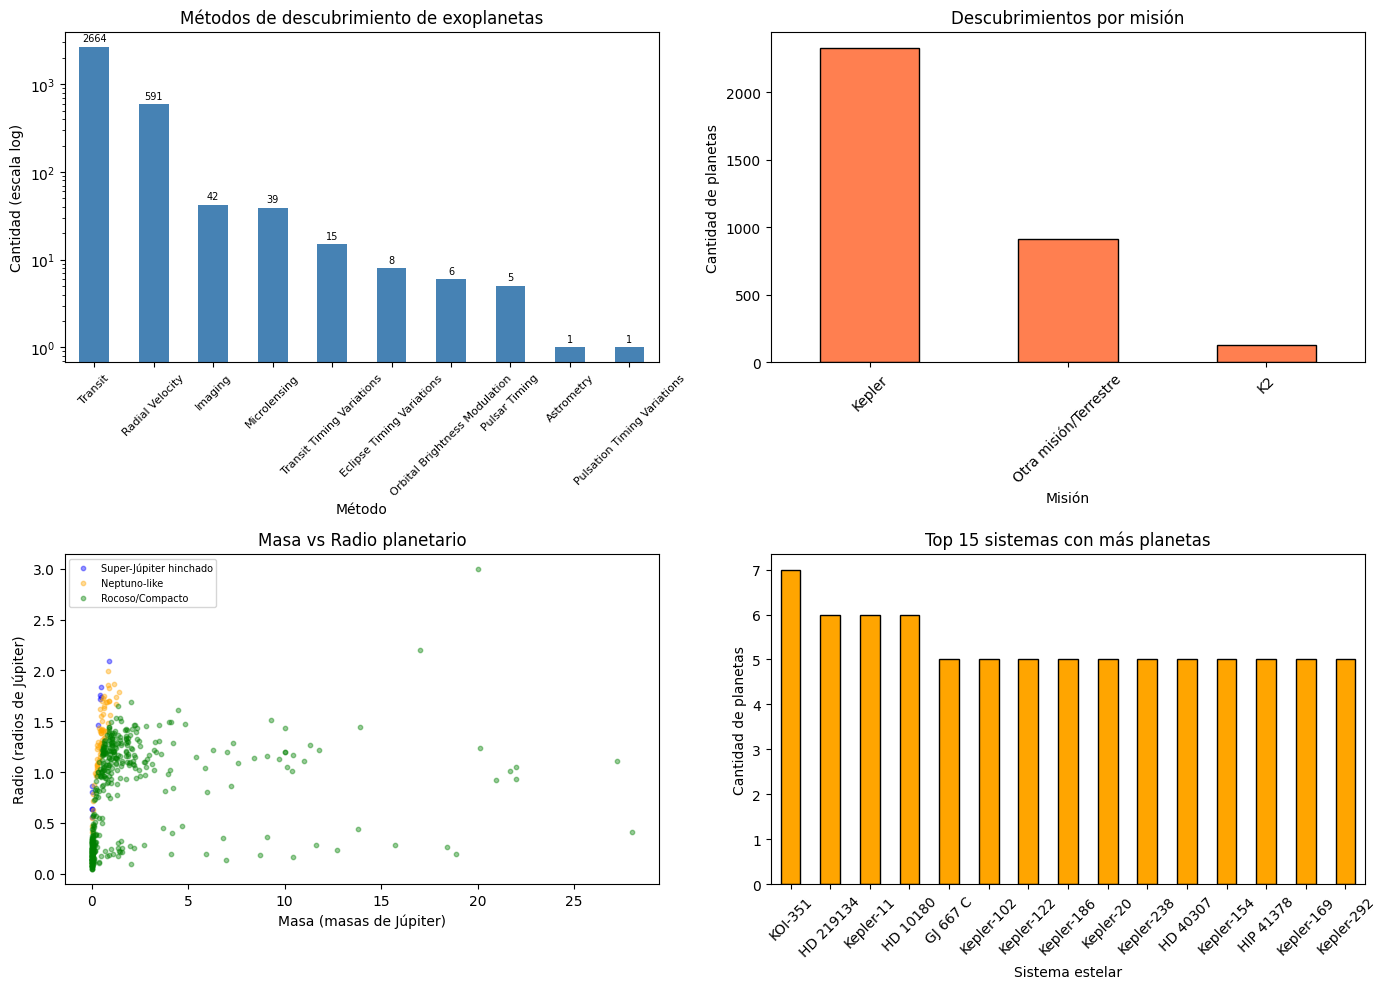

In [12]:
# ============================================================
# Entrega
# ============================================================

# --- 1. Visualización: Distribución de métodos de descubrimiento ---

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Métodos de descubrimiento (barras verticales con escala log para ver todos los valores)
counts = df_clean['pl_discmethod'].value_counts()
counts.plot(kind='bar', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_yscale('log')
axes[0, 0].set_title('Métodos de descubrimiento de exoplanetas')
axes[0, 0].set_xlabel('Método')
axes[0, 0].set_ylabel('Cantidad (escala log)')
axes[0, 0].tick_params(axis='x', rotation=45, labelsize=8)
# Anotar el valor exacto sobre cada barra
for i, (val, name) in enumerate(zip(counts.values, counts.index)):
    axes[0, 0].text(i, val * 1.1, str(val), ha='center', va='bottom', fontsize=7)

# Gráfico 2: Descubrimientos por misión
df_clean.groupby('discovery_mission')['pl_name'].count().sort_values(ascending=False).plot(
    kind='bar', ax=axes[0, 1], color='coral', edgecolor='black')
axes[0, 1].set_title('Descubrimientos por misión')
axes[0, 1].set_xlabel('Misión')
axes[0, 1].set_ylabel('Cantidad de planetas')
axes[0, 1].tick_params(axis='x', rotation=45)

# Gráfico 3: Masa vs Radio (coloreado por tipo de planeta)
# Usamos datos ORIGINALES de masa y radio para que se vea la dispersión real
colores = {'Super-Júpiter hinchado': 'blue', 'Neptuno-like': 'orange', 'Rocoso/Compacto': 'green'}
mask = df_clean['planet_type'].notna() & df['pl_bmassj'].notna() & df['pl_radj'].notna()
for tipo in df_clean['planet_type'].cat.categories:
    idx = mask & (df_clean['planet_type'] == tipo)
    axes[1, 0].scatter(df.loc[idx, 'pl_bmassj'], df.loc[idx, 'pl_radj'], alpha=0.4, s=10,
                        color=colores.get(tipo, 'gray'), label=tipo)
axes[1, 0].set_title('Masa vs Radio planetario')
axes[1, 0].set_xlabel('Masa (masas de Júpiter)')
axes[1, 0].set_ylabel('Radio (radios de Júpiter)')
axes[1, 0].legend(fontsize=7, loc='upper left')

# Gráfico 4: Planetas por sistema estelar (top 15)
top_systems = df_clean.groupby('pl_hostname')['pl_letter'].count().sort_values(ascending=False).head(15)
top_systems.plot(kind='bar', ax=axes[1, 1], color='orange', edgecolor='black')
axes[1, 1].set_title('Top 15 sistemas con más planetas')
axes[1, 1].set_xlabel('Sistema estelar')
axes[1, 1].set_ylabel('Cantidad de planetas')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Reflexión Grupal

**1. ¿Qué decisiones de limpieza fueron distintas entre grupos?**

En nuestro caso, las decisiones clave fueron:
- Eliminar columnas con >80% de nulos en vez de intentar imputarlas, porque con tan pocos datos reales la imputación sería poco confiable.
- Eliminar todas las columnas de error (`*err1`, `*err2`) y flags técnicos (`*lim`, `*blend`) porque no aportan al análisis de características de los exoplanetas.
- Usar la **mediana** para imputar columnas numéricas, ya que las variables astronómicas tienen distribuciones muy sesgadas (ej. `pl_orbper` con media=2,725 pero mediana=12.8).
- Usar la **moda** para imputar las categóricas (`pl_bmassprov`, `st_optband`).
- Corregir outliers con **capping IQR** en vez de eliminar filas, para no perder datos valiosos.

In [13]:
df2 = pd.read_csv('Datos/planets_clean.csv')
df2.head(20)

,pl_hostname,pl_letter,pl_discmethod,pl_pnum,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmassj,pl_bmassprov,pl_radj,...,pl_density_norm,st_dist_norm,st_optmag_norm,st_teff_norm,st_mass_norm,st_rad_norm,pl_discmethod_cod,pl_letter_cod,pl_bmassprov_cod,st_optband_cod
0,11 Com,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.081307,0.000000,0.237521,1.000000,1.000000,7,0,2,1
1,11 UMi,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.088006,0.000000,0.105066,1.000000,1.000000,7,0,2,1
2,14 And,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.055396,0.534880,0.260914,1.000000,1.000000,7,0,2,0
3,14 Her,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.011309,0.000000,0.425000,0.427083,0.479167,7,0,2,1
4,16 Cyg B,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.013777,0.000000,0.544605,0.520833,0.479167,7,0,2,1
5,18 Del,b,Radial Velocity,1,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.052905,0.534880,0.315610,1.000000,1.000000,7,0,2,0
6,1RXS J160929.1-210524,b,Imaging,1,12.794585,0.219188,0.1065,1.015,Mass,0.203,...,0.002084,0.107332,0.534880,0.012809,0.375000,0.479167,2,0,0,0
7,24 Sex,b,Radial Velocity,2,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.054185,0.000000,0.354819,1.000000,1.000000,7,0,2,1
8,24 Sex,c,Radial Velocity,2,100.192488,0.219188,0.1065,1.015,Msini,0.203,...,0.002084,0.054185,0.000000,0.354819,1.000000,1.000000,7,1,2,1
9,2MASS J01225093-2439505,b,Imaging,1,12.794585,0.219188,0.1065,1.015,Mass,0.203,...,0.002084,0.024821,0.558235,0.000000,0.000000,0.479167,2,0,0,1


## evaluación 2

2.1:

## Regresión logística

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

feature_cols = [
    'pl_orbper_norm', 'pl_orbsmax_norm', 'pl_orbeccen_norm',
    'pl_bmassj_norm', 'pl_radj_norm', 'pl_density_norm',
    'st_dist_norm', 'st_optmag_norm', 'st_teff_norm',
    'st_mass_norm', 'st_rad_norm',
    'pl_discmethod_cod', 'pl_letter_cod', 'pl_bmassprov_cod', 'st_optband_cod'
]

# Eliminar filas donde planet_type sea NaN
df_model = df2[feature_cols + ['planet_type']].dropna(subset=['planet_type'])

X = df_model[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(df_model[feature_cols].median())
y = df_model['planet_type']

print(f"Filas usadas para entrenar: {len(df_model)}")
print(f"Clases: {y.unique()}")

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

y_proba = clf.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f'ROC_AUC: {roc_auc}')

Filas usadas para entrenar: 509
Clases: <StringArray>
['Rocoso/Compacto', 'Neptuno-like', 'Super-Júpiter hinchado']
Length: 3, dtype: str
Accuracy: 0.8366013071895425
F1 Score: 0.7621705859093341
ROC_AUC: 0.7649926549344582


## Árbol de decisión

Accuracy: 0.7647058823529411
F1 Score: 0.7627995901153793
ROC_AUC: 0.5733333333333334


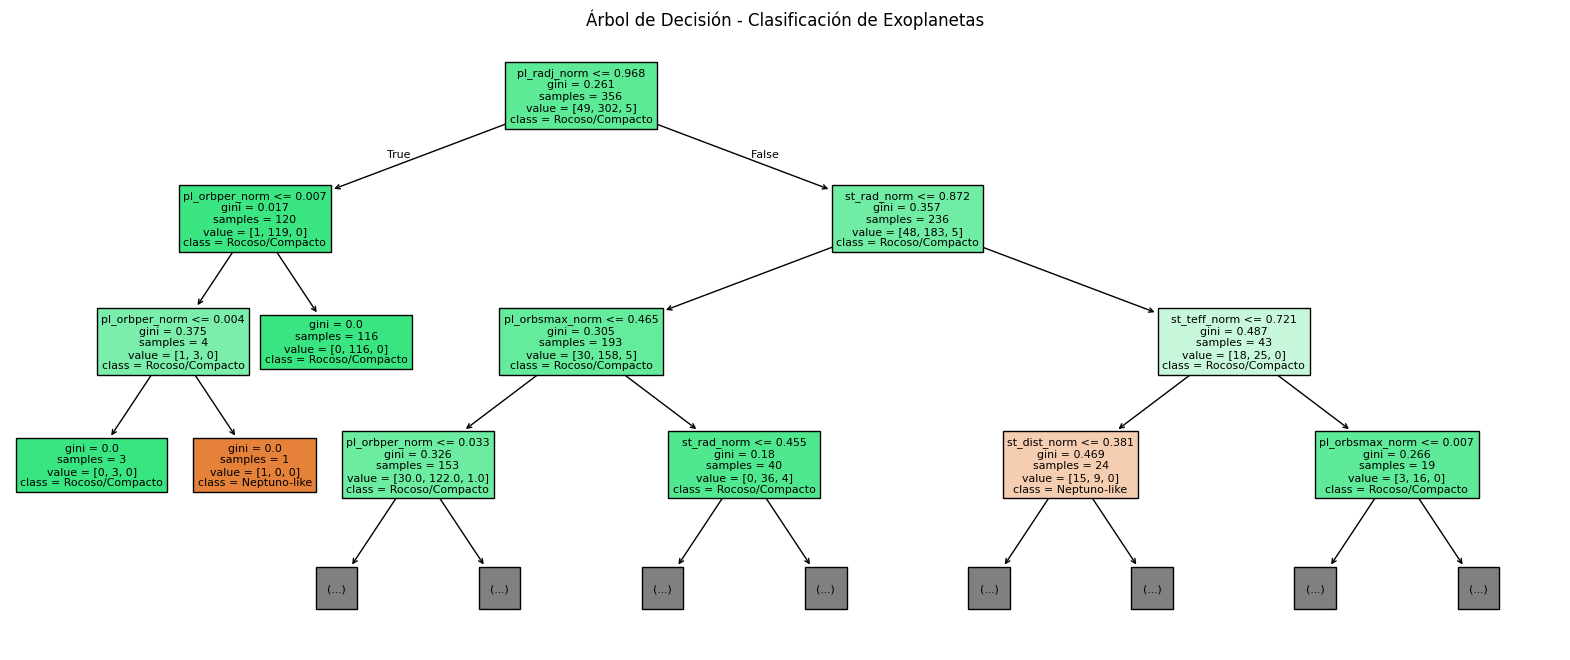

In [15]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

feature_cols = [
    'pl_orbper_norm', 'pl_orbsmax_norm', 'pl_orbeccen_norm',
    'pl_bmassj_norm', 'pl_radj_norm', 'pl_density_norm',
    'st_dist_norm', 'st_optmag_norm', 'st_teff_norm',
    'st_mass_norm', 'st_rad_norm',
    'pl_discmethod_cod', 'pl_letter_cod', 'pl_bmassprov_cod', 'st_optband_cod'
]

df_model = df2[feature_cols + ['planet_type']].dropna(subset=['planet_type'])
X = df_model[feature_cols].apply(pd.to_numeric, errors='coerce').fillna(df_model[feature_cols].median())
y = df_model['planet_type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf_tree = DecisionTreeClassifier(random_state=1)
clf_tree.fit(X_train, y_train)
y_pred = clf_tree.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))

y_proba = clf_tree.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
print(f'ROC_AUC: {roc_auc}')

# Gráfico del árbol
plt.figure(figsize=(20, 8))
plot_tree(clf_tree, 
        feature_names=feature_cols, 
        class_names=clf_tree.classes_, 
        filled=True, 
        max_depth=3)  # max_depth=3 para que sea legible
plt.title('Árbol de Decisión - Clasificación de Exoplanetas')
plt.show()

## Regresión Lineal

,pl_bmassj,pl_radj
0,1.015,0.203
1,1.015,0.203
2,1.015,0.203
3,1.015,0.203
4,1.015,0.203


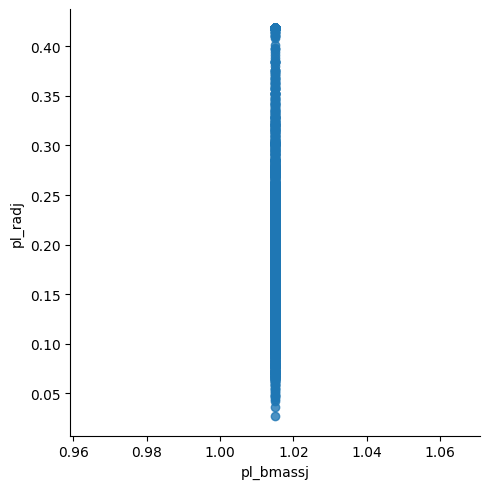

-0.00014229665252707413


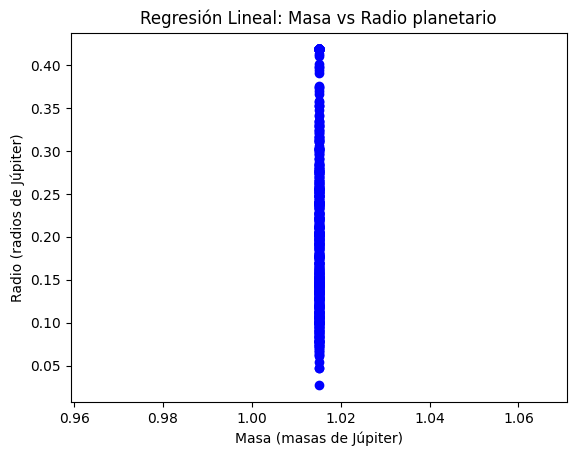

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Usar solo dos columnas para la regresión lineal: masa (pl_bmassj) y radio (pl_radj)
df_binary = df2[['pl_bmassj', 'pl_radj']].dropna()

# Mostrar primeras filas
display(df_binary.head())

# Scatter con línea de regresión
sns.lmplot(x='pl_bmassj', y='pl_radj', data=df_binary, order=1, ci=None)
plt.show()

df_binary.dropna(inplace=True)

# Convertir a numpy arrays y dividir en train/test
X = np.array(df_binary['pl_bmassj']).reshape(-1, 1)
y = np.array(df_binary['pl_radj']).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(regr.score(X_test, y_test))

y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='b')
plt.plot(X_test, y_pred, color='k')
plt.title('Regresión Lineal: Masa vs Radio planetario')
plt.xlabel('Masa (masas de Júpiter)')
plt.ylabel('Radio (radios de Júpiter)')
plt.show()

,pl_bmassj,pl_radj
0,1.015,0.203
1,1.015,0.203
2,1.015,0.203
3,1.015,0.203
4,1.015,0.203


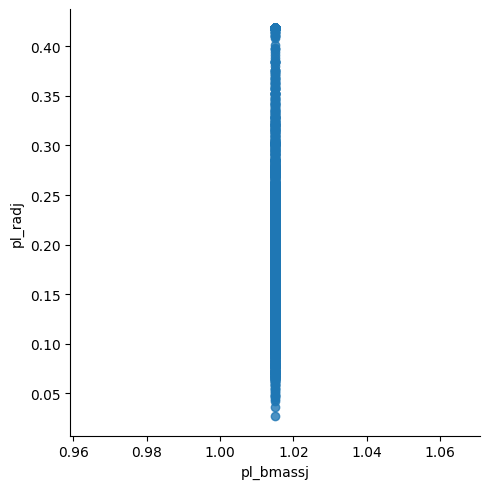

R²: -0.0000


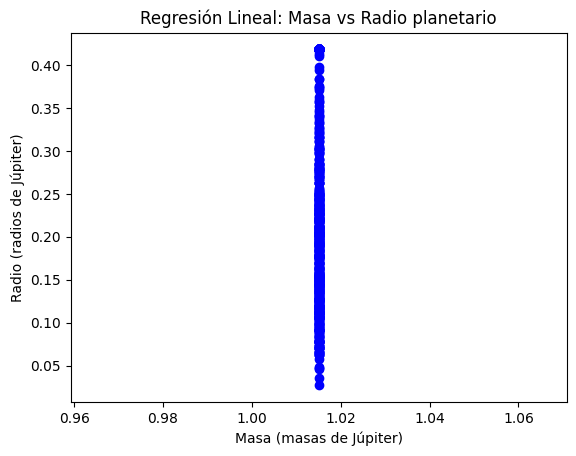

In [ ]:
#segundo intento con el arbol de decision
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Filtrar outliers extremos (percentil 1 al 99)
df_binary = df2[['pl_bmassj', 'pl_radj']].dropna()
q_low = df_binary['pl_bmassj'].quantile(0.01)
q_high = df_binary['pl_bmassj'].quantile(0.99)
df_binary = df_binary[(df_binary['pl_bmassj'] >= q_low) & (df_binary['pl_bmassj'] <= q_high)]

display(df_binary.head())

# Scatter con línea de regresión
sns.lmplot(x='pl_bmassj', y='pl_radj', data=df_binary, order=1, ci=None)
plt.show()

X = np.array(df_binary['pl_bmassj']).reshape(-1, 1)
y = np.array(df_binary['pl_radj']).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(f'R²: {regr.score(X_test, y_test):.4f}')

y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='b')
plt.plot(X_test, y_pred, color='k')
plt.title('Regresión Lineal: Masa vs Radio planetario')
plt.xlabel('Masa (masas de Júpiter)')
plt.ylabel('Radio (radios de Júpiter)')
plt.show()

In [24]:
# Ver distribución de columnas numéricas
df2[['pl_orbper', 'pl_orbsmax', 'pl_orbeccen', 'pl_bmassj', 'pl_radj', 
     'st_dist', 'st_teff', 'st_mass', 'st_rad']].describe()

,pl_orbper,pl_orbsmax,pl_orbeccen,pl_bmassj,pl_radj,st_dist,st_teff,st_mass,st_rad
count,3372.000000,3372.000000,3.372000e+03,3.372000e+03,3372.000000,3372.000000,3372.000000,3372.000000,3372.000000
mean,30.740163,0.128592,1.065000e-01,1.015000e+00,0.222992,540.062313,5499.205249,0.971498,1.033879
std,35.977661,0.056543,1.387985e-17,4.441551e-16,0.099723,358.384065,619.706615,0.220043,0.321188
min,0.090706,0.032888,1.065000e-01,1.015000e+00,0.027000,3.210000,4021.125000,0.490000,0.290000
25%,4.878436,0.102750,1.065000e-01,1.015000e+00,0.153000,303.000000,5159.250000,0.850000,0.830000
50%,12.794585,0.122000,1.065000e-01,1.015000e+00,0.203000,511.500000,5626.000000,0.970000,0.980000
75%,43.004057,0.149325,1.065000e-01,1.015000e+00,0.259000,711.500000,5918.000000,1.090000,1.190000
max,100.192488,0.219188,1.065000e-01,1.015000e+00,0.418000,1324.250000,7056.125000,1.450000,1.730000


In [ ]:
#  Durante el análisis exploratorio de los datos, se identificó que las
#  columnas pl_bmassj y pl_orbeccen presentaban una desviación estándar
#  prácticamente igual a cero, lo que indica que todos sus valores son
#  constantes a lo largo del dataset. Esto se debe a que el proceso de
#  limpieza y normalización previo del dataset dejó estas columnas sin
#  variabilidad real, haciendo imposible establecer una relación lineal
#  entre ellas. Por esta razón, se optó por utilizar las variables 
# st_teff (temperatura efectiva de la estrella) y st_rad (radio estelar), las
#  cuales presentan una distribución adecuada y una relación física coherente:
#  estrellas más calientes tienden a tener radios mayores, lo que las convierte
#  en candidatas idóneas para aplicar un modelo de regresión lineal.

,st_teff,st_rad
0,4742.0,1.73
1,4340.0,1.73
2,4813.0,1.73
3,5311.0,0.98
4,5674.0,0.98


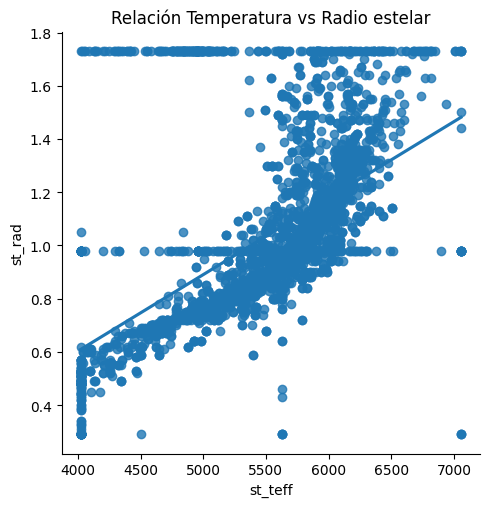

R²: 0.2717


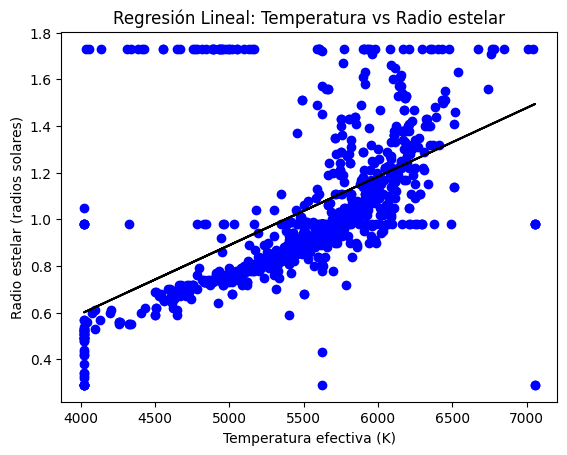

In [25]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Columnas con buena distribución
df_binary = df2[['st_teff', 'st_rad']].dropna()

display(df_binary.head())

# Scatter con línea de regresión
sns.lmplot(x='st_teff', y='st_rad', data=df_binary, order=1, ci=None)
plt.title('Relación Temperatura vs Radio estelar')
plt.show()

X = np.array(df_binary['st_teff']).reshape(-1, 1)
y = np.array(df_binary['st_rad']).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

regr = LinearRegression()
regr.fit(X_train, y_train)
print(f'R²: {regr.score(X_test, y_test):.4f}')

y_pred = regr.predict(X_test)
plt.scatter(X_test, y_test, color='b')
plt.plot(X_test, y_pred, color='k')
plt.title('Regresión Lineal: Temperatura vs Radio estelar')
plt.xlabel('Temperatura efectiva (K)')
plt.ylabel('Radio estelar (radios solares)')
plt.show()